# k Nearest Neighbors

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Partitioner import getDefaultWineSets
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [44]:
# get shared group split
X_train, X_val, X_test, y_train, y_val, y_test = getDefaultWineSets()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (3897, 12)
Validation shape: (1300, 12)
Test shape: (1300, 12)


In [45]:
# scale using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


In [46]:
# try one k first
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# validation prediction
y_val_pred = knn.predict(X_val_scaled)
y_test_pred_baseline = knn.predict(X_test_scaled)

print("Baseline validation accuracy (k=5):", accuracy_score(y_val, y_val_pred))
print("Baseline test accuracy (k=5):", accuracy_score(y_test, y_test_pred_baseline))

Baseline validation accuracy (k=5): 0.5546153846153846
Baseline test accuracy (k=5): 0.5615384615384615


In [47]:
#tuning the K using validation set
k_values = range(1, 31)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_val_pred = knn.predict(X_val_scaled)
    val_accuracies.append(accuracy_score(y_val, y_val_pred))

best_index = np.argmax(val_accuracies)
best_k = list(k_values)[best_index]
best_val_acc = val_accuracies[best_index]

print("Best k:", best_k)
print("Best validation accuracy:", best_val_acc)

Best k: 1
Best validation accuracy: 0.6138461538461538


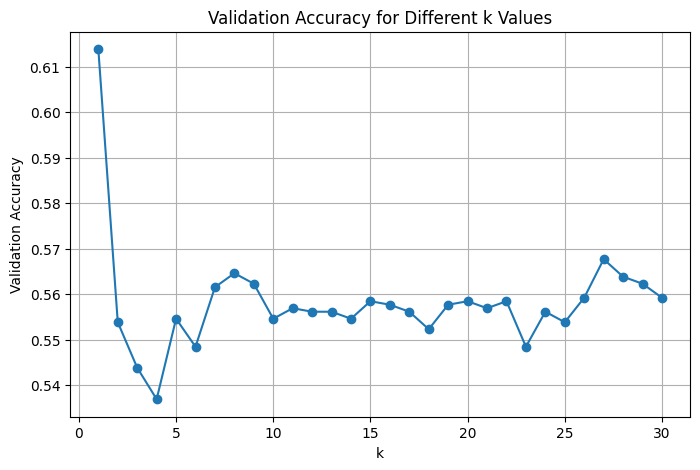

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different k Values")
plt.grid(True)
plt.show()

In [49]:
# train final model with best k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_val_pred_final = final_knn.predict(X_val_scaled)
y_test_pred = final_knn.predict(X_test_scaled)

print("Final validation accuracy:", accuracy_score(y_val, y_val_pred_final))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Final validation accuracy: 0.6138461538461538
Test accuracy: 0.5676923076923077


In [50]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.12      0.12      0.12        40
           5       0.61      0.64      0.63       419
           6       0.58      0.59      0.58       564
           7       0.57      0.52      0.54       231
           8       0.38      0.36      0.37        39
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1300
   macro avg       0.32      0.32      0.32      1300
weighted avg       0.57      0.57      0.57      1300

Confusion Matrix:
[[  0   2   2   2   0   0   0]
 [  0   5  24  10   1   0   0]
 [  0  16 269 122   8   4   0]
 [  3  14 131 330  74  12   0]
 [  1   3  11  90 120   6   0]
 [  0   0   2  16   7  14   0]
 [  0   0   0   0   0   1   0]]


/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set 

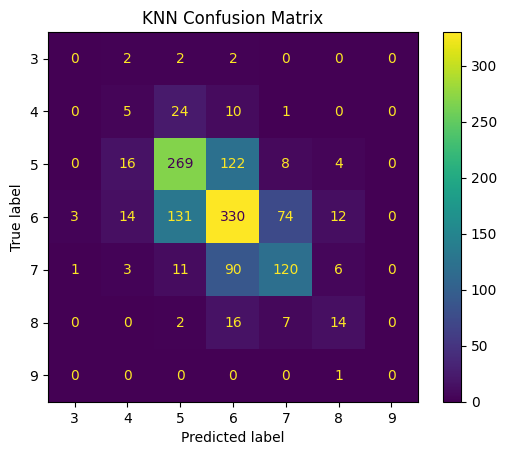

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title("KNN Confusion Matrix")
plt.show()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  wine_type  
0      9.4        5          0  
1      9.8        5 

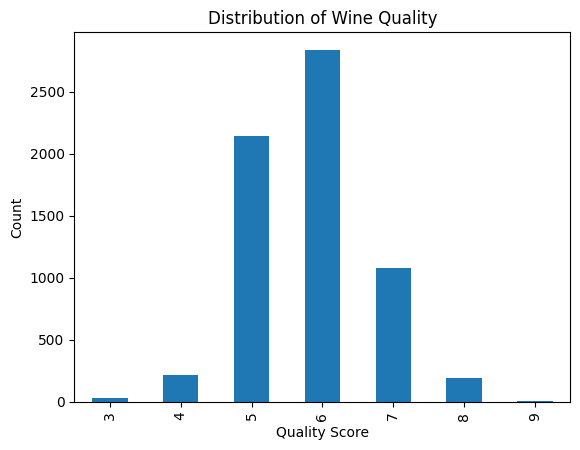

In [ ]:
red = pd.read_csv("wine+quality/winequality-red.csv", sep=";")
white = pd.read_csv("wine+quality/winequality-white.csv", sep=";")

red["wine_type"] = 0
white["wine_type"] = 1

wine = pd.concat([red, white], ignore_index=True)

print(wine.head())

wine["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

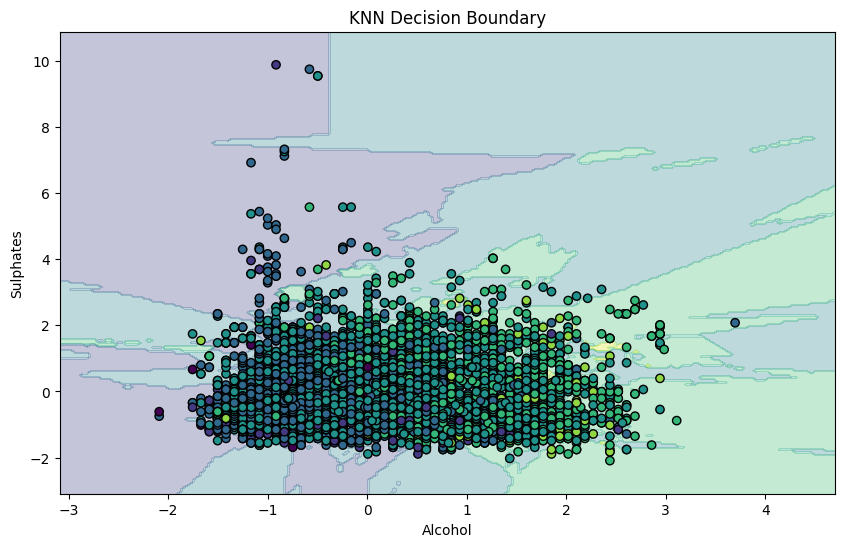

In [ ]:
X = wine[["alcohol", "sulphates"]]
y = wine["quality"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_scaled, y)

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor='k')

plt.xlabel("Alcohol")
plt.ylabel("Sulphates")
plt.title("KNN Decision Boundary")
plt.show()

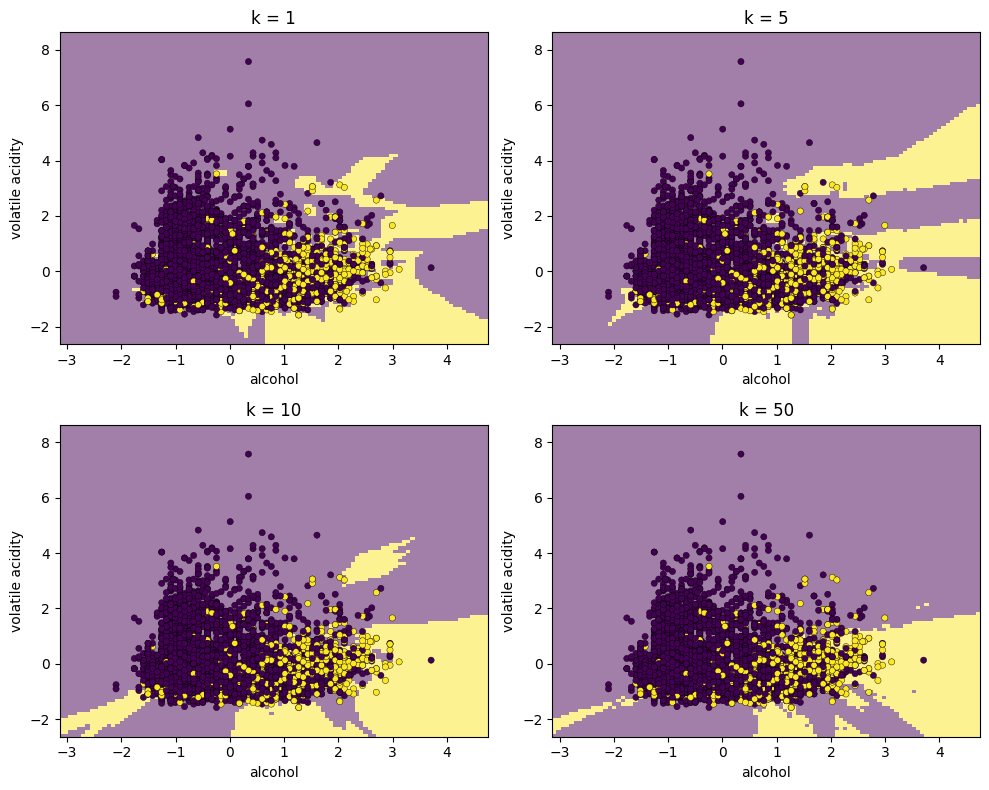

In [60]:

red["wine_type"] = 0
white["wine_type"] = 1


wine = pd.concat([red, white], ignore_index=True)


wine["good_quality"] = (wine["quality"] >= 7).astype(int)

# choose ONLY TWO features for plotting
X = wine[["alcohol", "volatile acidity"]]
y = wine["good_quality"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, stratify=y
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


figure, axes = plt.subplots(2, 2, figsize=(10, 8))

k_values = [1, 5, 10, 50]

for ax, k in zip(axes.ravel(), k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    DecisionBoundaryDisplay.from_estimator(
        knn,
        X_train_scaled,
        ax=ax,
        **plot_kwargs
    )

    ax.scatter(
        X_train_scaled[:, 0],
        X_train_scaled[:, 1],
        c=y_train,
        s=20,
        edgecolors="k",
        linewidths=0.3
    )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("alcohol")
    ax.set_ylabel("volatile acidity")

plt.tight_layout()
plt.show()